Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import joblib

pd.set_option("display.max_columns", None)

Load the Clean Dataset

In [15]:
df = pd.read_csv(
    "../../dataset/processed/traffic_cleaned.csv"
)

print(df.shape)

df.head()

(179649, 18)


,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index,Congestion Level,date,month,day,day_of_week,is_weekend,is_peak_hour,time_of_day,congestion_category
0,2024-12-16 14:39:24,SEG-0162239,6.863982,13.298207,14,95.3,23.1,1,20.6,Low,2024-12-16,December,Monday,Monday,0,0,Afternoon,Low
1,2025-03-01 15:41:09,SEG-0117236,6.969183,14.701078,15,92.3,36.0,0,23.1,Low,2025-03-01,March,Saturday,Saturday,1,0,Afternoon,Low
2,2024-11-16 11:28:45,SEG-0024260,4.801158,2.687999,11,51.9,32.1,0,42.4,Moderate,2024-11-16,November,Saturday,Saturday,1,0,Morning,Moderate
3,2025-06-11 11:54:33,SEG-0093490,4.871314,8.517009,11,54.6,38.8,1,9.0,Low,2025-06-11,June,Wednesday,Wednesday,0,0,Morning,Low
4,2024-12-28 07:33:06,SEG-0162248,6.062270,10.121534,7,29.6,55.4,0,67.1,High,2024-12-28,December,Saturday,Saturday,1,1,Morning,High


Inspect the Target : 
congestion_category

In [16]:
df["congestion_category"].value_counts()

congestion_category
Moderate    95885
Low         40628
High        39718
Severe       3418
Name: count, dtype: int64

Percentages

In [17]:
(
    df["congestion_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

congestion_category
Moderate    53.37
Low         22.62
High        22.11
Severe       1.90
Name: proportion, dtype: float64

Visualize

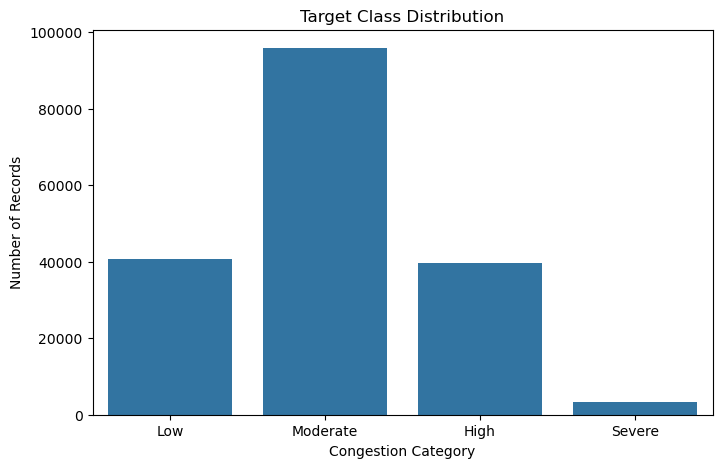

In [5]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="congestion_category",
    order=["Low", "Moderate", "High", "Severe"]
)

plt.title("Target Class Distribution")
plt.xlabel("Congestion Category")
plt.ylabel("Number of Records")

plt.show()

Feature_Columns

In [7]:
feature_columns = [
    "segment_id",
    "lat",
    "lon",
    "hour",
    "avg_speed_kmh",
    "density_veh_per_km",
    "incidents",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "time_of_day"
]

Target

In [8]:
target_column = "congestion_category"

Create x and y

In [9]:
X = df[feature_columns]

y = df[target_column]

Check

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (179649, 11)
y shape: (179649,)


Identify Feature Types

Numerical:

In [11]:
numeric_features = [
    "lat",
    "lon",
    "hour",
    "avg_speed_kmh",
    "density_veh_per_km",
    "incidents",
    "is_weekend",
    "is_peak_hour"
]

Categorical

In [12]:
categorical_features = [
    "segment_id",
    "day_of_week",
    "time_of_day"
]

Train/Test Split

In [18]:
df = df.sort_values("timestamp")

Check Current Columns

In [19]:
print(df.columns.tolist())

['timestamp', 'segment_id', 'lat', 'lon', 'hour', 'avg_speed_kmh', 'density_veh_per_km', 'incidents', 'congestion_index', 'Congestion Level', 'date', 'month', 'day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'time_of_day', 'congestion_category']


Convert Timestamp

In [20]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

Verify

In [21]:
print(df["timestamp"].dtype)

datetime64[ns]


Sort Chronologically

In [22]:
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,segment_id,lat,lon,hour,avg_speed_kmh,density_veh_per_km,incidents,congestion_index,Congestion Level,date,month,day,day_of_week,is_weekend,is_peak_hour,time_of_day,congestion_category
0,2024-10-11 22:29:13,SEG-0068600,10.109002,5.374449,22,58.8,46.8,0,2.0,Low,2024-10-11,October,Friday,Friday,0,0,Night,Low
1,2024-10-11 22:35:17,SEG-0129028,7.983461,11.962450,22,78.7,86.3,0,34.4,Moderate,2024-10-11,October,Friday,Friday,0,0,Night,Moderate
2,2024-10-11 22:35:23,SEG-0136849,6.403893,6.362146,22,54.2,56.6,0,39.7,Moderate,2024-10-11,October,Friday,Friday,0,0,Night,Moderate
3,2024-10-11 22:43:36,SEG-0066283,9.665242,10.600289,22,42.8,16.1,0,28.7,Moderate,2024-10-11,October,Friday,Friday,0,0,Night,Moderate
4,2024-10-11 22:44:06,SEG-0082773,7.635434,11.760034,22,44.9,82.2,1,50.2,High,2024-10-11,October,Friday,Friday,0,0,Night,High


Verify

In [23]:
print(df["timestamp"].min())
print(df["timestamp"].max())

2024-10-11 22:29:13
2025-10-11 22:26:38


Create the Time-Based Train/Test Split

In [24]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Training records:", len(train_df))
print("Testing records:", len(test_df))

Training records: 143719
Testing records: 35930


Verify There Is No Time Leakage

In [25]:
print("Training ends:", train_df["timestamp"].max())
print("Testing starts:", test_df["timestamp"].min())

Training ends: 2025-07-31 02:28:39
Testing starts: 2025-07-31 02:29:40


In [26]:
assert train_df["timestamp"].max() < test_df["timestamp"].min()

print("Temporal split validation passed.")

Temporal split validation passed.


Don't Use Timestamp Directly as a Feature

In [27]:
feature_columns = [
    "segment_id",
    "lat",
    "lon",
    "hour",
    "avg_speed_kmh",
    "density_veh_per_km",
    "incidents",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "time_of_day"
]

target_column = "congestion_category"

In [28]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

Load and sort the cleaned dataset

In [29]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../../dataset/processed/traffic_cleaned.csv"
)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

df = df.sort_values("timestamp").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Dataset shape: (179649, 18)
Start: 2024-10-11 22:29:13
End: 2025-10-11 22:26:38


Remove any previously created target

In [30]:
if "congestion_category" in df.columns:
    df = df.drop(columns=["congestion_category"])

Create chronological train/test sets

In [31]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Training records:", len(train_df))
print("Testing records:", len(test_df))

Training records: 143719
Testing records: 35930


Verify

In [32]:
print("Training ends:", train_df["timestamp"].max())
print("Testing starts:", test_df["timestamp"].min())

Training ends: 2025-07-31 02:28:39
Testing starts: 2025-07-31 02:29:40


In [33]:
assert train_df["timestamp"].max() < test_df["timestamp"].min()

print("Temporal split validation passed.")

Temporal split validation passed.


Create congestion categories from training data only

This is th

In [34]:
q1 = train_df["congestion_index"].quantile(0.25)
q2 = train_df["congestion_index"].quantile(0.50)
q3 = train_df["congestion_index"].quantile(0.75)

print("Congestion thresholds:")
print(f"Q1: {q1:.2f}")
print(f"Q2: {q2:.2f}")
print(f"Q3: {q3:.2f}")

Congestion thresholds:
Q1: 26.40
Q2: 38.00
Q3: 49.50


In [35]:
def create_congestion_category(series, q1, q2, q3):
    return pd.cut(
        series,
        bins=[
            -np.inf,
            q1,
            q2,
            q3,
            np.inf
        ],
        labels=[
            "Low",
            "Moderate",
            "High",
            "Severe"
        ]
    )

Apply the training thresholds to both datasets:

In [36]:
train_df["congestion_category"] = create_congestion_category(
    train_df["congestion_index"],
    q1,
    q2,
    q3
)

test_df["congestion_category"] = create_congestion_category(
    test_df["congestion_index"],
    q1,
    q2,
    q3
)

Check the target distribution

Training

In [37]:
print("Training distribution:")
print(train_df["congestion_category"].value_counts())

Training distribution:
congestion_category
Low         36064
High        35999
Moderate    35910
Severe      35746
Name: count, dtype: int64


Testing

In [38]:
print("\nTesting distribution:")
print(test_df["congestion_category"].value_counts())


Testing distribution:
congestion_category
Severe      9022
High        9007
Moderate    8953
Low         8948
Name: count, dtype: int64


Percentages

In [39]:
print(
    train_df["congestion_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

congestion_category
Low         25.09
High        25.05
Moderate    24.99
Severe      24.87
Name: proportion, dtype: float64


Define Features

Now select the information the model is allowed to see.

In [40]:
feature_columns = [
    "segment_id",
    "lat",
    "lon",
    "hour",
    "avg_speed_kmh",
    "density_veh_per_km",
    "incidents",
    "day_of_week",
    "is_weekend",
    "is_peak_hour",
    "time_of_day"
]

target_column = "congestion_category"

Create x and y

In [41]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

Check 

In [42]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (143719, 11)
y_train: (143719,)
X_test: (35930, 11)
y_test: (35930,)


Confirm no target leakage

In [43]:
leakage_columns = [
    "congestion_index",
    "congestion_category",
    "timestamp"
]

print("Model features:")
print(X_train.columns.tolist())

for column in leakage_columns:
    assert column not in X_train.columns, (
        f"Potential leakage detected: {column}"
    )

print("No direct target leakage detected.")

Model features:
['segment_id', 'lat', 'lon', 'hour', 'avg_speed_kmh', 'density_veh_per_km', 'incidents', 'day_of_week', 'is_weekend', 'is_peak_hour', 'time_of_day']
No direct target leakage detected.


Separate categorical and numerical features

In [44]:
numeric_features = [
    "lat",
    "lon",
    "hour",
    "avg_speed_kmh",
    "density_veh_per_km",
    "incidents",
    "is_weekend",
    "is_peak_hour"
]

categorical_features = [
    "segment_id",
    "day_of_week",
    "time_of_day"
]

Build the preprocessing pipeline

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

Create a baseline model

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score


baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

Train

In [47]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['lat', 'lon', 'hour',
                                                   'avg_speed_kmh',
                                                   'density_veh_per_km',
                                                   'incidents', 'is_weekend',
                                                   'is_peak_hour']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['segment_id', 'day_of_week',
                                                   'time_of_day'])])),
                ('classifier', DummyClassifier(strategy='most_frequent'))])

Predict

In [48]:
baseline_predictions = baseline_model.predict(X_test)

Evaluate

In [49]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="weighted"
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline F1 Score: {baseline_f1:.4f}")

Baseline Accuracy: 0.2490
Baseline F1 Score: 0.0993


Train Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

Train

In [51]:
decision_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['lat', 'lon', 'hour',
                                                   'avg_speed_kmh',
                                                   'density_veh_per_km',
                                                   'incidents', 'is_weekend',
                                                   'is_peak_hour']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['segment_id', 'day_of_week',
                                                   'time_of_day'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        random_state=42))])

Predict

In [52]:
dt_predictions = decision_tree.predict(X_test)

Evaluate

In [53]:
dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

dt_f1 = f1_score(
    y_test,
    dt_predictions,
    average="weighted"
)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree F1: {dt_f1:.4f}")

Decision Tree Accuracy: 0.7341
Decision Tree F1: 0.7325


Train Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier


random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

Train

In [55]:
random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['lat', 'lon', 'hour',
                                                   'avg_speed_kmh',
                                                   'density_veh_per_km',
                                                   'incidents', 'is_weekend',
                                                   'is_peak_hour']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['segment_id', 'day_of_week',
                                                   'time_of_day'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_split=5, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

Predict

In [56]:
rf_predictions = random_forest.predict(X_test)

Evaluate Random Forest

In [57]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")

Random Forest Accuracy: 0.4346
Random Forest F1 Score: 0.3928


Full Classification Report

In [58]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.34      0.15      0.21      9007
         Low       0.39      0.70      0.50      8948
    Moderate       0.34      0.17      0.23      8953
      Severe       0.57      0.72      0.63      9022

    accuracy                           0.43     35930
   macro avg       0.41      0.43      0.39     35930
weighted avg       0.41      0.43      0.39     35930



Confusion Matrix

In [59]:
from sklearn.metrics import confusion_matrix

labels = [
    "Low",
    "Moderate",
    "High",
    "Severe"
]

cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=labels
)

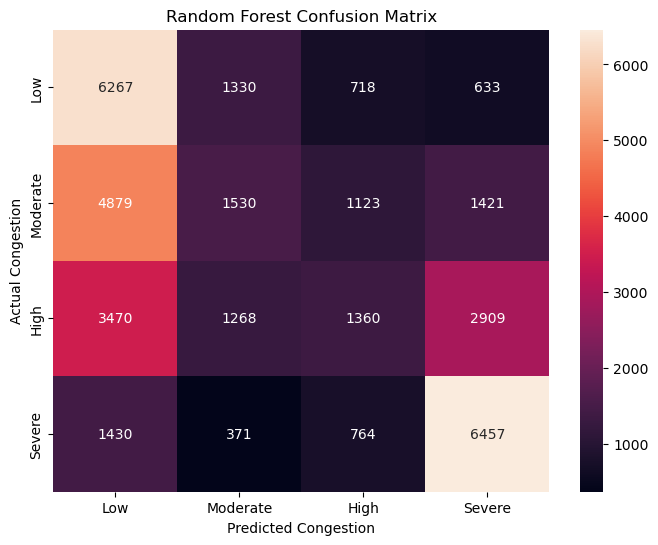

In [60]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Congestion")
plt.ylabel("Actual Congestion")

plt.show()

Compare the Models

In [61]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Weighted F1": [
        baseline_f1,
        dt_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Weighted F1
0,Baseline,0.249040,0.099310
1,Decision Tree,0.734094,0.732457
2,Random Forest,0.434567,0.392763


Visualize

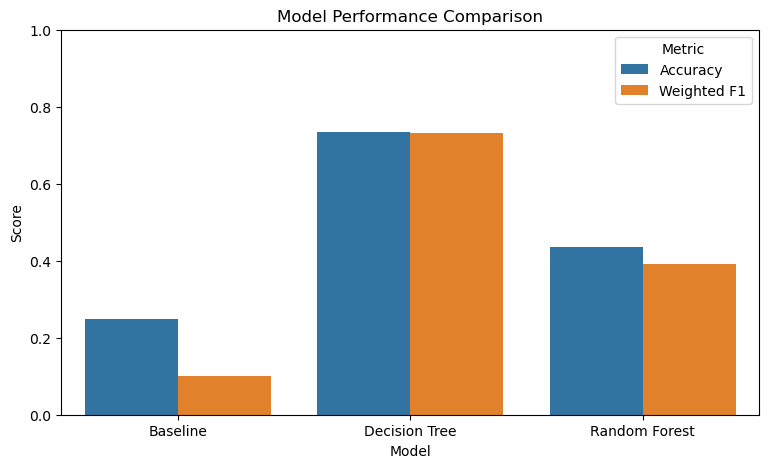

In [62]:
plt.figure(figsize=(9, 5))

results_melted = results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Weighted F1"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.title("Model Performance Comparison")

plt.show()

Save the Best Model

In [63]:
import os
import joblib

os.makedirs(
    "../../ml/models",
    exist_ok=True
)

joblib.dump(
    random_forest,
    "../../ml/models/traffic_congestion_model.pkl"
)

print("Traffic congestion model saved successfully.")

Traffic congestion model saved successfully.


Test the Saved Model

In [64]:
loaded_model = joblib.load(
    "../../ml/models/traffic_congestion_model.pkl"
)

Take one test observation:

In [65]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Congestion:", prediction[0])

Predicted Congestion: Low


For possibilty

In [66]:
probabilities = loaded_model.predict_proba(sample)

print(probabilities)

[[0.24139384 0.27825791 0.25809986 0.2222484 ]]


Save the Training Metadata

In [67]:
metadata = {
    "model": "RandomForestClassifier",
    "target": "congestion_category",
    "classes": labels,
    "features": feature_columns,
    "train_size": len(train_df),
    "test_size": len(test_df),
    "congestion_thresholds": {
        "q1": float(q1),
        "q2": float(q2),
        "q3": float(q3)
    },
    "accuracy": float(rf_accuracy),
    "weighted_f1": float(rf_f1)
}

Save it

In [68]:
import json

with open(
    "../../ml/models/model_metadata.json",
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("Model metadata saved.")

Model metadata saved.


Document the Milestone

# Milestone 5 Summary

## Problem Type

Multi-class traffic congestion classification.

## Target

`congestion_category`

The target consists of:

- Low
- Moderate
- High
- Severe

## Data Split

A chronological 80/20 train-test split was used.

The model was trained on historical observations and evaluated on later observations to reduce temporal data leakage.

## Features

The model uses:

- Segment ID
- Latitude
- Longitude
- Hour
- Average speed
- Traffic density
- Incidents
- Day of week
- Weekend indicator
- Peak-hour indicator
- Time of day

The following were excluded:

- `timestamp` — used for chronological ordering only.
- `congestion_index` — excluded to prevent target leakage.
- `congestion_category` — target variable.

## Models

Three models were evaluated:

1. Dummy Classifier
2. Decision Tree
3. Random Forest

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- Weighted F1-score
- Confusion Matrix

## Selected Model

The model with the strongest generalization performance will be selected for deployment.

## Model Artifact

`ml/models/traffic_congestion_model.pkl`

In [69]:
import sklearn
import joblib

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
joblib: 1.4.2


In [70]:
import numpy
import joblib
import sklearn

print("NumPy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

NumPy: 2.1.3
scikit-learn: 1.6.1
joblib: 1.4.2
